In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error

# Fonts and tick marks and such
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Georgia', 'Times New Roman', 'DejaVu Serif'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'grid.linewidth': 0.6,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.facecolor': '#FAFAF8',
    'axes.facecolor': '#FAFAF8',
})

# Colors
NAVY             = '#2C3E6B'
RED              = '#C0392B'
GREEN            = '#27AE60'
AMBER            = '#E67E22'
TEAL             = '#16A085'
LIGHT            = '#FAFAF8'
OBSERVED_COLOR   = '#2C3E6B'
PREDICTED_COLOR  = '#C0392B'
FORECAST_COLOR   = '#27AE60'
CI_COLOR         = '#A8D5B5'
DIVIDER_COLOR    = '#999999'

# Labels for variables (full name and measurement scale)
VAR_LABELS = {
    'tasmax'            : 'Max temperature (°C)',
    'tasmin'            : 'Min temperature (°C)',
    'rsds'              : 'Solar radiation (W/m²)',
    'sfcWind'           : 'Wind speed (m/s)',
    'ps'                : 'Surface pressure (Pa)',
    'pr'                : 'Precipitation (kg/m²/s)',
    'Anxiety Disorders' : 'Anxiety disorders\n(per 100k visits)',
}

# Load and prep weather data
weather = pd.read_csv('San_Francisco_climate_v2.csv')
weather['time'] = pd.to_datetime(weather['time'])
weather['year']  = weather['time'].dt.year
weather['month'] = weather['time'].dt.month
weather = weather.groupby(['year', 'month']).mean().reset_index()
weather = weather.drop(columns=['time'], errors='ignore')
# Make months cyclical so that the model understands the order
# of months e.g., Jan comes after Dec and Feb comes after Jan
# (aka they aren't just numbers 1-12 that repeat anymore)
weather['month_sin'] = np.sin(2 * np.pi * weather['month'] / 12)
weather['month_cos'] = np.cos(2 * np.pi * weather['month'] / 12)

# Load and prep mental health data to get anxiety
mental = pd.read_csv('mental_health_ED.csv')
ANXIETY_COL = 'Anxiety Disorders'
mental = mental[mental['demographics_values'] == 'All']
mental = mental[mental['condition'] == 'Anxiety Disorders']
mental['month_end'] = pd.to_datetime(mental['month_end'])
# Pivot so that it is in same format as weather data
mental_pivot = mental.pivot_table(
    index='month_end',
    values='rate_per_100000_visits'
).reset_index()
mental_pivot.columns = ['month_end', ANXIETY_COL]
mental_pivot['month_end'] = pd.to_datetime(mental_pivot['month_end'])
mental_pivot['year']  = mental_pivot['month_end'].dt.year
mental_pivot['month'] = mental_pivot['month_end'].dt.month
mental_pivot = mental_pivot.drop(columns='month_end')

# Merge into one data set
combined = weather.merge(mental_pivot, on=['year', 'month'], how='inner')
print(combined.shape)
print(combined.columns.tolist())

# Features are months
X = combined[['month_sin', 'month_cos']]

# BRR loop for all variables
time_cols = ['year', 'month', 'month_sin', 'month_cos']
all_vars  = [col for col in combined.columns if col not in time_cols]
all_vars  = [col for col in all_vars if combined[col].dtype != 'datetime64[ns]']

results = {}
for var in all_vars:
    y = combined[var]
    # Train data is 2019 - 2023 (~70% of data)
    train_mask = (combined['year'] >= 2019) & (combined['year'] <= 2023)
    # Test data is 2024-2025 (~30% of data)
    test_mask  =  combined['year'] >= 2024
    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]
    clf = linear_model.BayesianRidge()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_true = y_test.values
    # MAE as validation metric
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    results[var] = {
        'model'      : clf,
        'mae'        : mae,
        'mae_train'  : mean_absolute_error(y_train, clf.predict(X_train)),  # <-- add
        'mape'       : mape,
        'y_pred'     : y_pred,
        'y_true'     : y_true,
        'test_index' : y_test.index,
        'y_fit'      : clf.predict(X_train),
        'train_mask' : train_mask,
    }
#     results[var] = {
#         'model'       : clf,
#         'mae'         : mae,
#         'mape'        : mape,
#         'y_pred'      : y_pred,
#         'y_true'      : y_true,
#         'test_index'  : y_test.index,
#         'y_fit'       : clf.predict(X_train),  
#         'train_mask'  : train_mask,            
#     }
#     print(f"{var}: MAE = {mae:.4f} | MAPE = {mape:.2f}%")
    mae_train = results[var]['mae_train']
    MAE_diff = round(abs(mae_train - mae),2)
    print(f"{var}: Train MAE = {results[var]['mae_train']:.4f} | Test MAE = {mae:.4f} | Difference = {MAE_diff} | MAPE = {mape:.2f}%")

# Future forecast May 2026 – May 2028 (NO MORE GROUND TRUTH)
future_dates = pd.date_range(start='2026-05-01', end='2028-05-01', freq='MS')
X_future = pd.DataFrame({
    'month_sin': np.sin(2 * np.pi * future_dates.month / 12),
    'month_cos': np.cos(2 * np.pi * future_dates.month / 12),
})
predictions_future = pd.DataFrame({
    'year' : future_dates.year,
    'month': future_dates.month,
})
for var in all_vars:
    predictions_future[var] = results[var]['model'].predict(X_future)

# Helper fcn
def make_dates(df):
    return pd.to_datetime(dict(year=df['year'], month=df['month'], day=1))

combined_dates  = make_dates(combined)
future_dates_dt = make_dates(predictions_future)
print(combined.head())

(84, 11)
['year', 'month', 'tasmax', 'tasmin', 'rsds', 'ps', 'pr', 'sfcWind', 'month_sin', 'month_cos', 'Anxiety Disorders']
tasmax: Train MAE = 1.0145 | Test MAE = 1.2959 | Difference = 0.28 | MAPE = 7.89%
tasmin: Train MAE = 0.7623 | Test MAE = 1.0081 | Difference = 0.25 | MAPE = 11.00%
rsds: Train MAE = 10.7583 | Test MAE = 11.4808 | Difference = 0.72 | MAPE = 6.35%
ps: Train MAE = 97.2024 | Test MAE = 92.4518 | Difference = 4.75 | MAPE = 0.09%
pr: Train MAE = 0.0000 | Test MAE = 0.0000 | Difference = 0.0 | MAPE = 217.85%
sfcWind: Train MAE = 0.3089 | Test MAE = 0.2809 | Difference = 0.03 | MAPE = 9.42%
Anxiety Disorders: Train MAE = 306.5845 | Test MAE = 308.5917 | Difference = 2.01 | MAPE = 12.54%
   year  month     tasmax     tasmin        rsds             ps            pr  \
0  2019      1  13.699859   8.268349   98.817619  101324.653645  2.121360e-05   
1  2019      2  13.220363   8.500450  121.474994  101205.964429  7.346358e-05   
2  2019      3  15.606182   8.493326  213.918

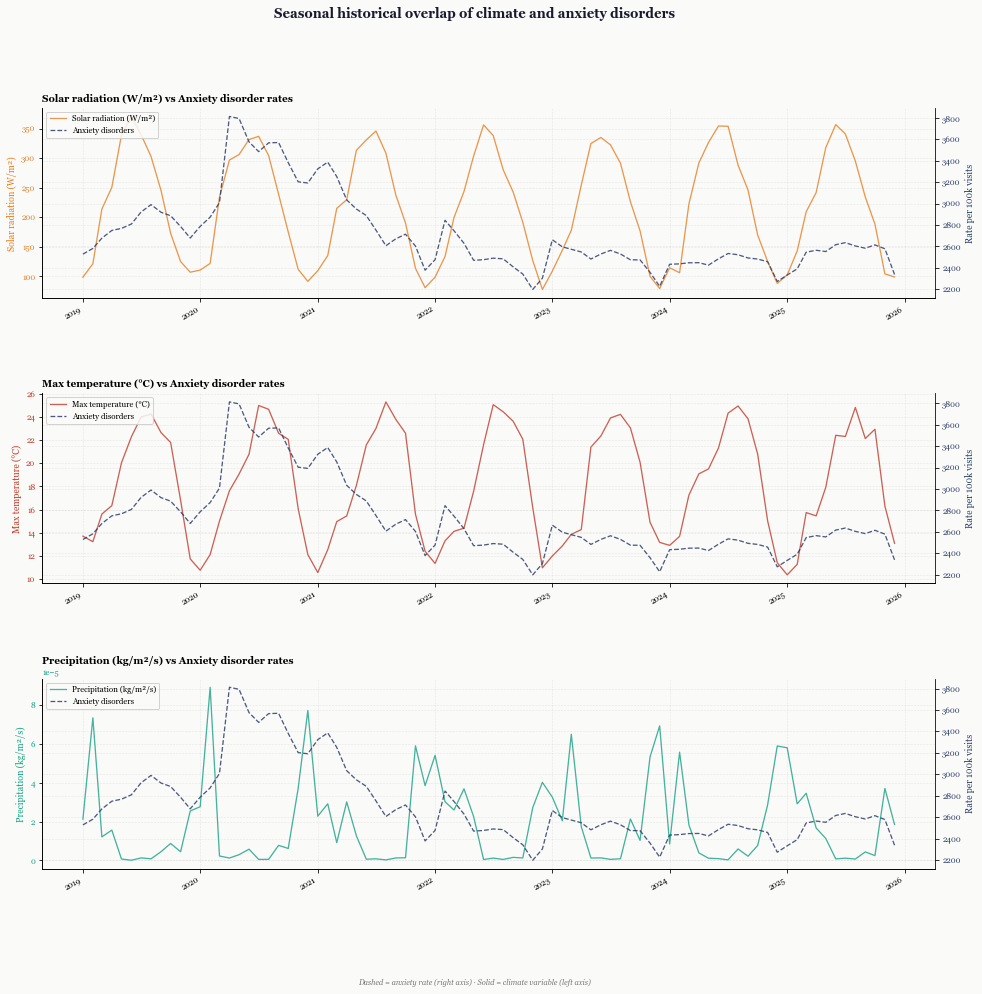

In [2]:
# Seasonal overlap figure
# of max temp and solar radiation (extreme heat variables)

fig1, axes1 = plt.subplots(3, 1, figsize=(16, 14), facecolor=LIGHT)
fig1.subplots_adjust(hspace=0.5)

for ax, weather_var, label, color in zip(
    axes1,
    ['rsds', 'tasmax', 'pr'],
    ['Solar radiation (W/m²)', 'Max temperature (°C)', 'Precipitation (kg/m²/s)'],
    [AMBER, RED, TEAL]
):
    ax2 = ax.twinx()
    ax.spines['right'].set_visible(True)
    ax.plot(combined_dates, combined[weather_var],
            color=color, linewidth=1.3, alpha=0.8, label=label)
    ax.set_ylabel(label, color=color, fontsize=9)
    ax.tick_params(axis='y', labelcolor=color)
    ax2.plot(combined_dates, combined[ANXIETY_COL],
             color=NAVY, linewidth=1.3, linestyle='--',
             alpha=0.85, label='Anxiety disorders')
    ax2.set_ylabel('Rate per 100k visits', color=NAVY, fontsize=9)
    ax2.tick_params(axis='y', labelcolor=NAVY)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2,
              fontsize=8, loc='upper left', framealpha=0.85, edgecolor='#CCCCCC')
    ax.set_title(f'{label} vs Anxiety disorder rates',
                 fontweight='bold', fontsize=10, loc='left')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig1.suptitle('Seasonal historical overlap of climate and anxiety disorders',
              fontsize=13, fontweight='bold', y=0.98, color='#1A1A2E')
fig1.text(0.5, 0.01,
          'Dashed = anxiety rate (right axis) · Solid = climate variable (left axis)',
          ha='center', fontsize=7.5, color='#777777', style='italic')
plt.savefig('fig1_seasonal_overlap.png', dpi=180, bbox_inches='tight', facecolor=LIGHT)
plt.show()



<ipython-input-15-fe18f952f75a>:87: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from current font.
  plt.savefig('fig2_brr_forecast.png', dpi=180, bbox_inches='tight', facecolor=LIGHT)


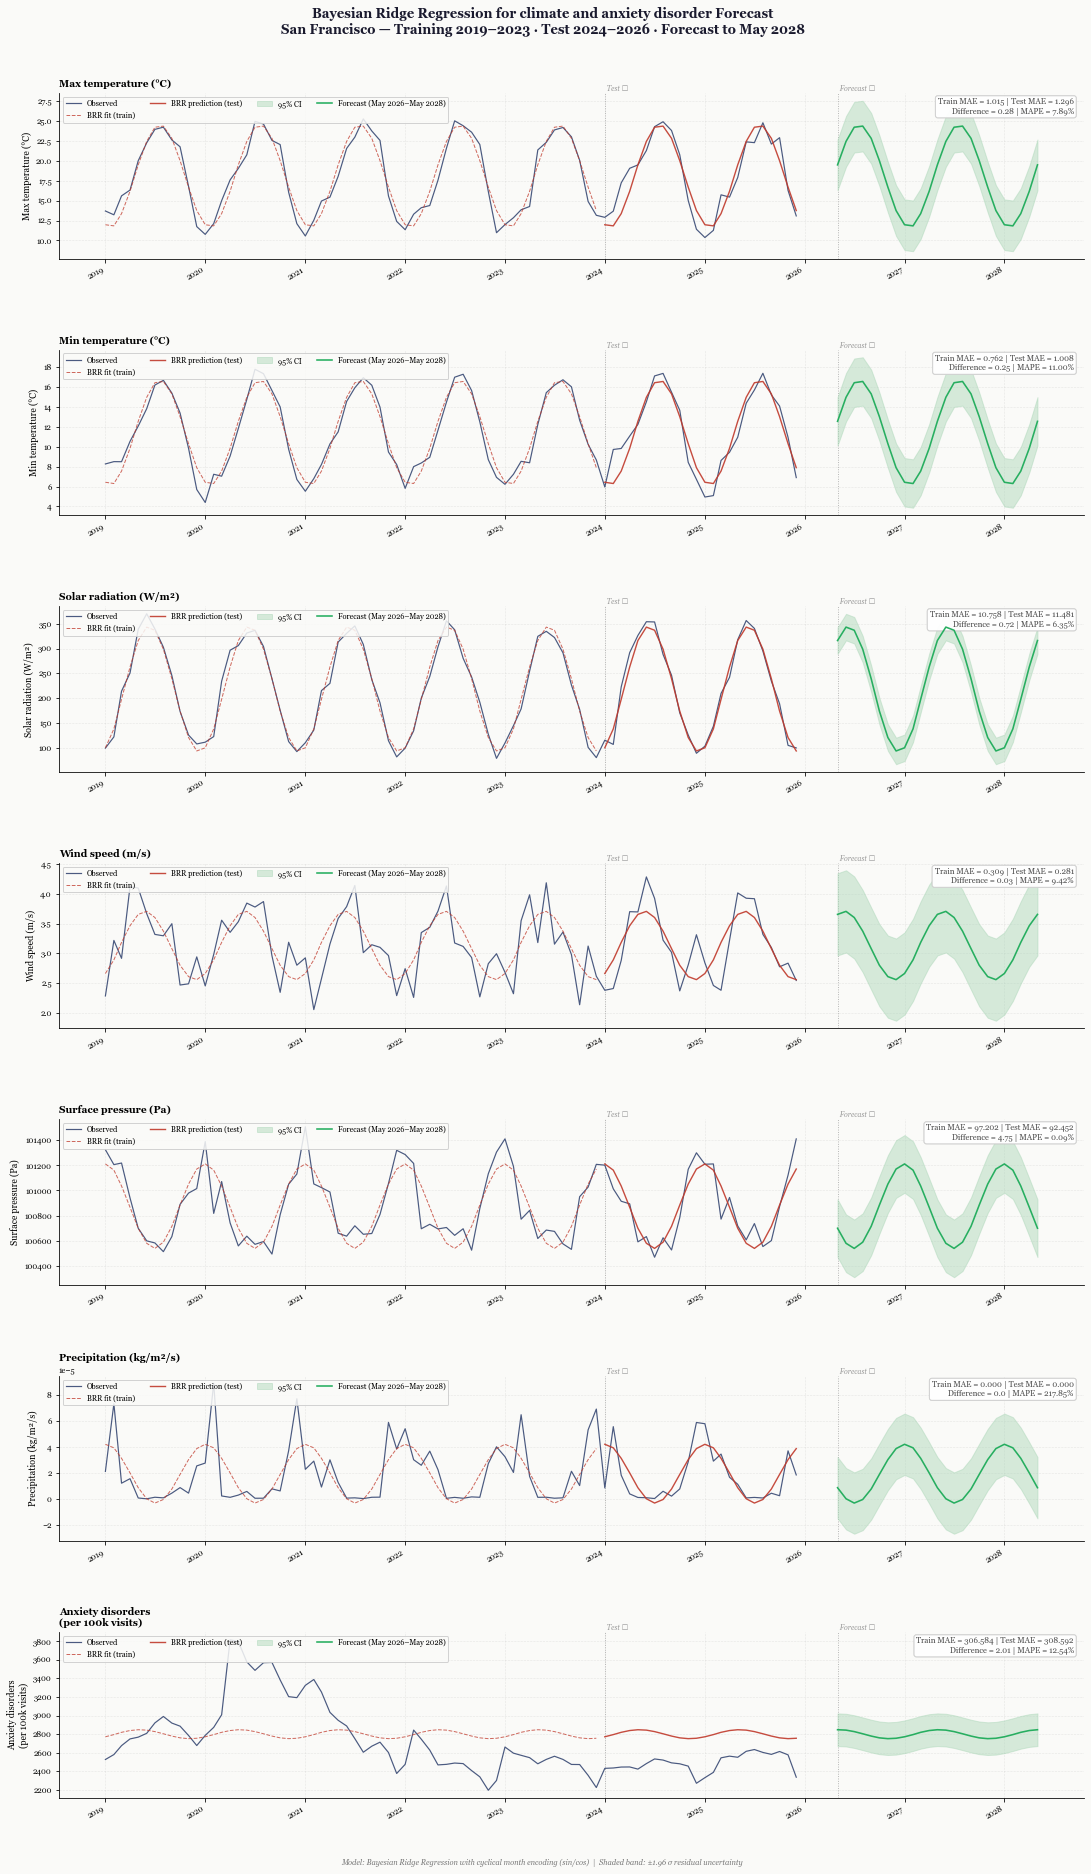

In [15]:
# BRR Forecast (all variables)

plot_vars = ['tasmax', 'tasmin', 'rsds', 'sfcWind', 'ps', 'pr', ANXIETY_COL]
n = len(plot_vars)

fig2 = plt.figure(figsize=(16, 3.8 * n), facecolor=LIGHT)
fig2.subplots_adjust(hspace=0.55, left=0.08, right=0.97, top=0.93, bottom=0.04)
gs = gridspec.GridSpec(n, 1, figure=fig2)

for i, var in enumerate(plot_vars):
    ax = fig2.add_subplot(gs[i])

    ax.plot(combined_dates, combined[var],
            color=OBSERVED_COLOR, linewidth=1.2, alpha=0.85,
            label='Observed', zorder=3)

    train_mask = results[var]['train_mask']
    y_fit      = results[var]['y_fit']
    ax.plot(combined_dates[train_mask], y_fit,
            color=PREDICTED_COLOR, linewidth=1.0, linestyle='--',
            alpha=0.75, label='BRR fit (train)', zorder=4)

    y_true = results[var]['y_true']
    y_pred = results[var]['y_pred']
    idx    = results[var]['test_index']
    order  = np.argsort(idx)
    test_dates = combined_dates[idx[order]]
    ax.plot(test_dates, y_pred[order],
            color=PREDICTED_COLOR, linewidth=1.4, linestyle='-',
            alpha=0.9, label='BRR prediction (test)', zorder=5)

    y_fc     = predictions_future[var].values
    y_fc_std = np.std(y_true - y_pred)
    ax.fill_between(future_dates_dt,
                    y_fc - 1.96 * y_fc_std,
                    y_fc + 1.96 * y_fc_std,
                    color=CI_COLOR, alpha=0.45, label='95% CI', zorder=2)
    ax.plot(future_dates_dt, y_fc,
            color=FORECAST_COLOR, linewidth=1.6,
            label='Forecast (May 2026–May 2028)', zorder=6)

    for xdate, lbl in [
        (pd.Timestamp('2024-01-01'), 'Test →'),
        (pd.Timestamp('2026-05-01'), 'Forecast →'),
    ]:
        ax.axvline(xdate, color=DIVIDER_COLOR, linewidth=0.9,
                   linestyle=':', alpha=0.8, zorder=1)
        ax.text(xdate, ax.get_ylim()[1], f' {lbl}',
                fontsize=7, color=DIVIDER_COLOR,
                va='bottom', ha='left', style='italic')

        mae_train = results[var]['mae_train']
        mae_test  = results[var]['mae']
        mape      = results[var]['mape']
        ax.text(0.99, 0.97,
                f'Train MAE = {mae_train:.3f} | Test MAE = {mae_test:.3f}\n Difference = {round(abs(mae_train-mae_test),2)} | MAPE = {mape:.2f}%',
                transform=ax.transAxes, fontsize=8,
                ha='right', va='top', color='#555555',
                bbox=dict(boxstyle='round,pad=0.3', fc='white',
                      ec='#CCCCCC', alpha=0.8))        
#         mae  = results[var]['mae']
#         mape = results[var]['mape']
#         ax.text(0.99, 0.97, f'MAE = {mae:.3f}  |  MAPE = {mape:.2f}%',
#             transform=ax.transAxes, fontsize=8,
#             ha='right', va='top', color='#555555',
#             bbox=dict(boxstyle='round,pad=0.3', fc='white',
#                   ec='#CCCCCC', alpha=0.8))

    ax.set_ylabel(VAR_LABELS.get(var, var), fontsize=9)
    ax.set_title(VAR_LABELS.get(var, var), fontweight='bold',
                 fontsize=10, loc='left', pad=6)
    ax.legend(fontsize=7.5, loc='upper left',
              framealpha=0.85, edgecolor='#CCCCCC', ncol=4)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig2.suptitle(
    'Bayesian Ridge Regression for climate and anxiety disorder Forecast\n'
    'San Francisco — Training 2019–2023 · Test 2024–2026 · Forecast to May 2028',
    fontsize=13, fontweight='bold', y=0.975, color='#1A1A2E'
)
fig2.text(0.5, 0.005,
          'Model: Bayesian Ridge Regression with cyclical month encoding (sin/cos)  '
          '|  Shaded band: ±1.96 σ residual uncertainty',
          ha='center', fontsize=7.5, color='#777777', style='italic')
plt.savefig('fig2_brr_forecast.png', dpi=180, bbox_inches='tight', facecolor=LIGHT)
plt.show()


<ipython-input-4-6b43b768ade2>:29: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from current font.
  plt.savefig('fig3_forecast.png', dpi=180, bbox_inches='tight', facecolor=LIGHT)


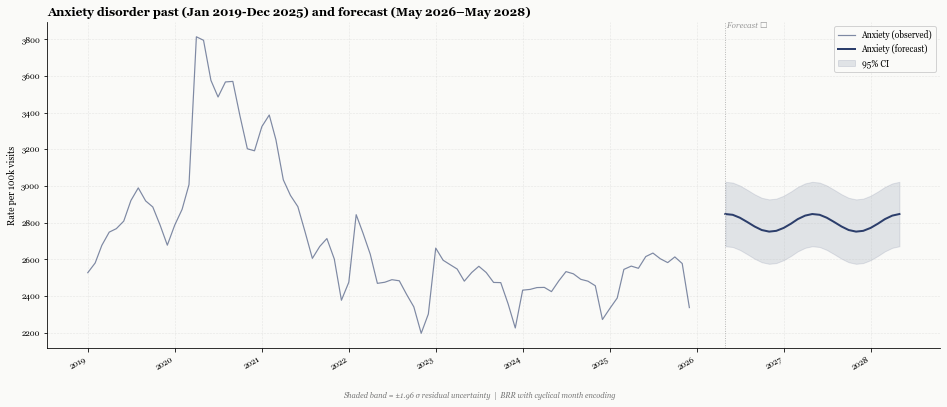

In [4]:
# Anxiety Forecast standalone figure

fig3, ax = plt.subplots(figsize=(16, 6), facecolor=LIGHT)

ax.plot(combined_dates, combined[ANXIETY_COL],
        color=NAVY, linewidth=1.2, alpha=0.6, label='Anxiety (observed)')
ax.plot(future_dates_dt, predictions_future[ANXIETY_COL],
        color=NAVY, linewidth=2.0, label='Anxiety (forecast)')

std = np.std(results[ANXIETY_COL]['y_true'] - results[ANXIETY_COL]['y_pred'])
fc  = predictions_future[ANXIETY_COL].values
ax.fill_between(future_dates_dt, fc - 1.96*std, fc + 1.96*std,
                color=NAVY, alpha=0.12, label='95% CI')

ax.axvline(pd.Timestamp('2026-05-01'), color='#999999',
           linewidth=0.9, linestyle=':', alpha=0.8)
ax.text(pd.Timestamp('2026-05-01'), ax.get_ylim()[1],
        ' Forecast →', fontsize=8, color='#999999', va='top', style='italic')
ax.set_title('Anxiety disorder past (Jan 2019-Dec 2025) and forecast (May 2026–May 2028)',
             fontweight='bold', fontsize=12, loc='left')
ax.set_ylabel('Rate per 100k visits', fontsize=9)
ax.legend(fontsize=8.5, framealpha=0.85, edgecolor='#CCCCCC')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
fig3.text(0.5, 0.01,
          'Shaded band = ±1.96 σ residual uncertainty  |  BRR with cyclical month encoding',
          ha='center', fontsize=7.5, color='#777777', style='italic')
plt.savefig('fig3_forecast.png', dpi=180, bbox_inches='tight', facecolor=LIGHT)
plt.show()



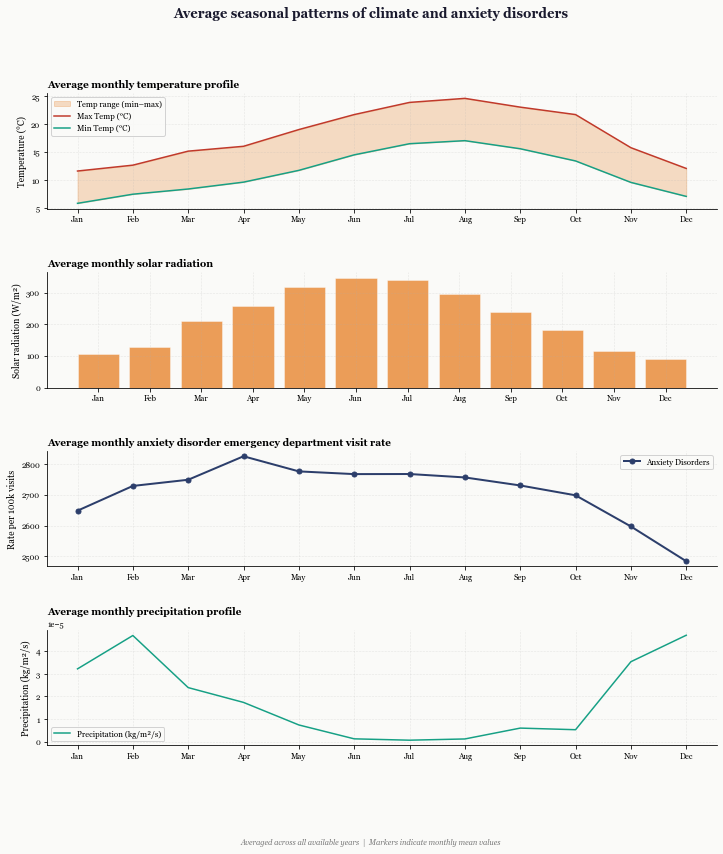

In [5]:
# FIGURE 4 — Monthly Profile (seasonal fingerprint)

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly = combined.groupby('month').mean().reset_index()

fig4, axes4 = plt.subplots(4, 1, figsize=(12, 12), facecolor=LIGHT)
fig4.subplots_adjust(hspace=0.55)

ax = axes4[0]
ax.fill_between(monthly['month'], monthly['tasmin'], monthly['tasmax'],
                color=AMBER, alpha=0.25, label='Temp range (min–max)')
ax.plot(monthly['month'], monthly['tasmax'], color=RED,  linewidth=1.5, label='Max Temp (°C)')
ax.plot(monthly['month'], monthly['tasmin'], color=TEAL, linewidth=1.5, label='Min Temp (°C)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylabel('Temperature (°C)', fontsize=9)
ax.set_title('Average monthly temperature profile',
             fontweight='bold', fontsize=10, loc='left')
ax.legend(fontsize=8, framealpha=0.85, edgecolor='#CCCCCC')

ax = axes4[1]
ax.bar(monthly['month'], monthly['rsds'],
       color=AMBER, alpha=0.75, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylabel('Solar radiation (W/m²)', fontsize=9)
ax.set_title('Average monthly solar radiation',
             fontweight='bold', fontsize=10, loc='left')

ax = axes4[2]
ax.plot(monthly['month'], monthly[ANXIETY_COL],
        color=NAVY, linewidth=2.0, marker='o', markersize=5, label='Anxiety Disorders')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylabel('Rate per 100k visits', fontsize=9)
ax.set_title('Average monthly anxiety disorder emergency department visit rate',
             fontweight='bold', fontsize=10, loc='left')
ax.legend(fontsize=8, framealpha=0.85, edgecolor='#CCCCCC')



ax = axes4[3]
ax.plot(monthly['month'], monthly['pr'], color=TEAL,  linewidth=1.5, label='Precipitation (kg/m²/s)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylabel('Precipitation (kg/m²/s)', fontsize=9)
ax.set_title('Average monthly precipitation profile',
             fontweight='bold', fontsize=10, loc='left')
ax.legend(fontsize=8, framealpha=0.85, edgecolor='#CCCCCC')



fig4.suptitle('Average seasonal patterns of climate and anxiety disorders',
              fontsize=13, fontweight='bold', y=0.98, color='#1A1A2E')
fig4.text(0.5, 0.01,
          'Averaged across all available years  |  Markers indicate monthly mean values',
          ha='center', fontsize=7.5, color='#777777', style='italic')
plt.savefig('fig4_monthly_profile.png', dpi=180, bbox_inches='tight', facecolor=LIGHT)
plt.show()

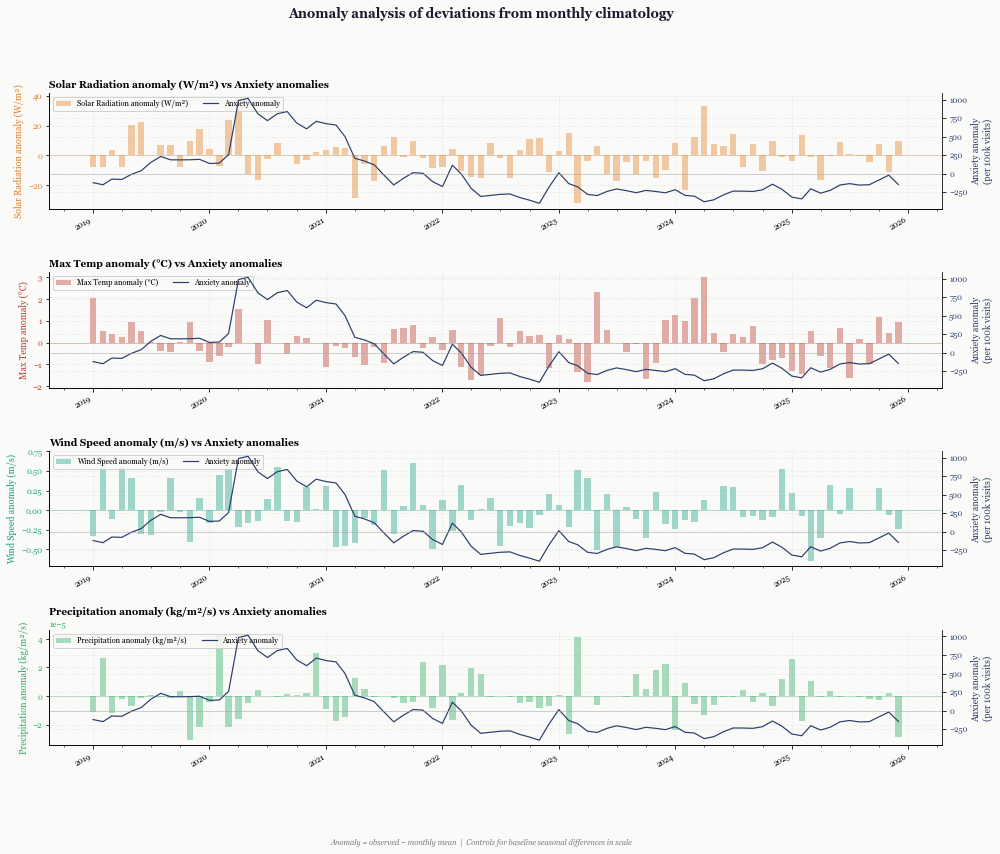

All figures saved.


In [6]:
# Anomaly figure

def compute_anomaly(df, col):
    monthly_mean = df.groupby('month')[col].transform('mean')
    return df[col] - monthly_mean

fig5, axes5 = plt.subplots(4, 1, figsize=(16, 12), facecolor=LIGHT)
fig5.subplots_adjust(hspace=0.55)

pairs = [
    ('rsds',    'Solar Radiation anomaly (W/m²)', AMBER),
    ('tasmax',  'Max Temp anomaly (°C)',           RED),
    ('sfcWind', 'Wind Speed anomaly (m/s)',         TEAL),
    ('pr', 'Precipitation anomaly (kg/m²/s)', GREEN),
]

for ax, (weather_var, ylabel, color) in zip(axes5, pairs):
    w_anom = compute_anomaly(combined, weather_var)
    a_anom = compute_anomaly(combined, ANXIETY_COL)
    ax2 = ax.twinx()
    ax.spines['right'].set_visible(True)
    ax.bar(combined_dates, w_anom, color=color, alpha=0.4, width=20, label=ylabel)
    ax.axhline(0, color=color, linewidth=0.6, alpha=0.5)
    ax.set_ylabel(ylabel, color=color, fontsize=9)
    ax.tick_params(axis='y', labelcolor=color)
    ax2.plot(combined_dates, a_anom, color=NAVY, linewidth=1.2, label='Anxiety anomaly')
    ax2.axhline(0, color='#AAAAAA', linewidth=0.5)
    ax2.set_ylabel('Anxiety anomaly\n(per 100k visits)', color=NAVY, fontsize=9)
    ax2.tick_params(axis='y', labelcolor=NAVY)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2,
              fontsize=7.5, loc='upper left', framealpha=0.85,
              edgecolor='#CCCCCC', ncol=2)
    ax.set_title(f'{ylabel} vs Anxiety anomalies',
                 fontweight='bold', fontsize=10, loc='left')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig5.suptitle('Anomaly analysis of deviations from monthly climatology',
              fontsize=13, fontweight='bold', y=0.98, color='#1A1A2E')
fig5.text(0.5, 0.01,
          'Anomaly = observed − monthly mean  |  Controls for baseline seasonal differences in scale',
          ha='center', fontsize=7.5, color='#777777', style='italic')
plt.savefig('fig5_anomaly_framing.png', dpi=180, bbox_inches='tight', facecolor=LIGHT)
plt.show()

print("All figures saved.")